In [6]:
from google.colab import files

import pandas as pd
from google.colab import files
uploaded = files.upload()
salaries = pd.read_csv('datascience_salaries.csv')
salaries.head()
salaries.describe()


Saving datascience_salaries.csv to datascience_salaries (2).csv


,Unnamed: 0,salary
count,1171.000000,1171.000000
mean,931.620837,64836.037575
std,647.445266,32551.767046
min,0.000000,30000.000000
25%,364.500000,45000.000000
50%,815.000000,63000.000000
75%,1504.500000,68000.000000
max,2259.000000,228000.000000


In [12]:
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1171 non-null   int64 
 1   job_title         1171 non-null   object
 2   job_type          1171 non-null   object
 3   experience_level  1171 non-null   object
 4   location          1171 non-null   object
 5   salary_currency   1171 non-null   object
 6   salary            1171 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 64.2+ KB


In [21]:

# salaries = salaries.drop(columns=['Unnamed: 0'])
print(salaries.head())



        job_title   job_type experience_level       location salary_currency  \
0  Data scientist  Full Time           Senior  New York City             USD   
1  Data scientist  Full Time           Senior         Boston             USD   
2  Data scientist  Full Time           Senior         London             USD   
3  Data scientist  Full Time           Senior         Boston             USD   
4  Data scientist  Full Time           Senior  New York City             USD   

   salary  
0  149000  
1  120000  
2   68000  
3  120000  
4  149000  


In [37]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

salaries['salary_normalized'] = scaler.fit_transform(salaries[['salary']])

print(salaries[['salary', 'salary_normalized']].head())

min_salary_normalized = salaries['salary_normalized'].min()
max_salary_normalized = salaries['salary_normalized'].max()

print("Min normalized salary:", min_salary_normalized)
print("Max normalized salary:", max_salary_normalized)



     salary  salary_normalized
0  2.586647           0.601010
1  1.695377           0.454545
2  0.097239           0.191919
3  1.695377           0.454545
4  2.586647           0.601010
Min normalized salary: 0.0
Max normalized salary: 1.0


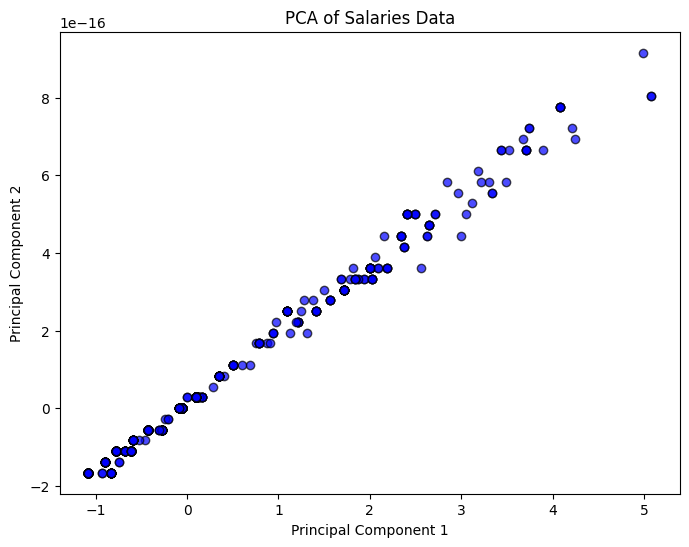

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
numeric_cols = salaries.select_dtypes(include=['float64', 'int64'])


pca = PCA(n_components=2)
pca_results = pca.fit_transform(numeric_cols)


salaries['PCA1'] = pca_results[:, 0]
salaries['PCA2'] = pca_results[:, 1]


plt.figure(figsize=(8, 6))
plt.scatter(salaries['PCA1'], salaries['PCA2'], c='blue', edgecolor='k', alpha=0.7)
plt.title('PCA of Salaries Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()



In [26]:
avg_salary_by_experience = salaries.groupby('experience_level')['salary'].mean()

print(avg_salary_by_experience)

experience_level
Entry        36111.111111
Executive    76076.923077
Mid          51786.885246
Senior       75088.033012
Name: salary, dtype: float64
